In [1]:
import numpy as np
from scipy import fft
import scipy as sp
from matplotlib import pyplot as plt

import schemdraw
from schemdraw import flow
import schemdraw as schem
import schemdraw.elements as e
from schemdraw import dsp

%config InlineBackend.figure_formats = ['svg']

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")


The Laplace transform is a time frequency transform allowing the analysis of continuous time LTI systems in terms of their impulse response behavior. This is relevant when designing and investigating filters or other processing units with a scope on their **stability**. 
The single-sided (or unilateral) Laplace transform is defined by the following integral:

$$\begin{eqnarray}
F(s) & = & \mathcal{L}\{f(t)\}  \\
 & = & \int\limits_0^\infty f(t) e^{-s t}  dt  
\end{eqnarray}$$

$s$ is the Laplace operator:

$$
s = \sigma + j \omega 
$$


For $\sigma=0$, the Laplace transform becomes the Fourier Transform:

$$
F(s) = \int\limits_0^\infty f(t) e^{-j \omega t}  dt = F(\omega)
$$


An addition in the exponent can be decomposed into two exponential terms:

$$\begin{eqnarray}
F(s) & = & \int\limits_0^\infty e^{-\sigma t -j \omega t} f(t) dt \\
& = & \int\limits_0^\infty e^{-\sigma t} \ e^{-j \omega t} f(t) dt
\end{eqnarray}$$

- The term $e^{-\sigma t}$ is referred to as the **decay term**.
- $ e^{-j \omega t}$ is called the **frequency term**.

With these two terms, the Laplace transform can be considered an extension of the Fourier transform.
While the latter *only* gives information on the frequency content of signals, the Laplace transform encodes the temporal behavior with the decay term and can be used to analyze the stability of LTI systems.


  

-------

# Visualisation

The following plots visualize the influence of the decay term and the frequency term.

## Changing $\sigma$

$\sigma$ is the decay factor. For $\sigma > 0$, the transform increases with time - this means an impulse response with such behavior belongs to an unstable system (for that frequency).
For $\sigma<0$, the transform decreases, indicating a stable system (for that frequency).
For $\sigma=0$ we see the Fourier terms.


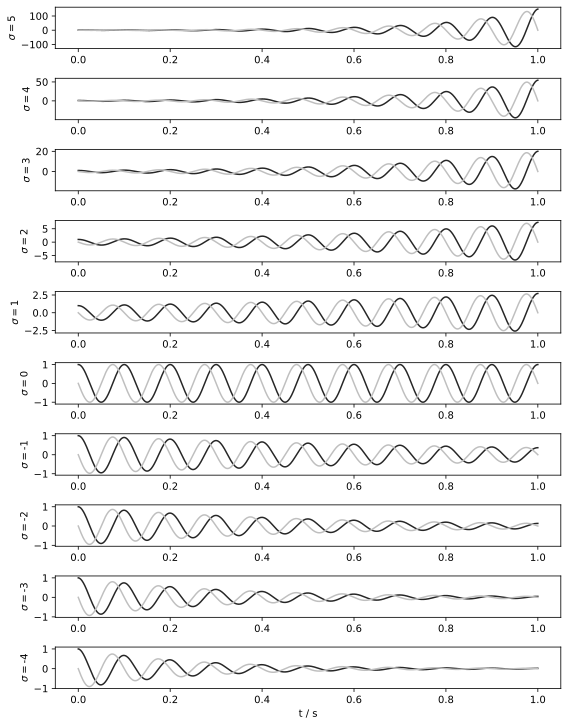

In [2]:
def laplace(t, s, w, r):
        
    out = np.zeros(len(t))
    
    for i in range(len(t)):
        val = t[i]
            
        if r ==1:    
            out[i] = np.real(np.exp(-s*val) * np.exp(-1j * w * val))
        else:
            out[i] = np.imag(np.exp(-s*val) * np.exp(-1j * w * val))
            
    return out



t = np.linspace(0,1,1000)

fig, axs = plt.subplots(10, 1, figsize=(8, 10))

for i in range(10):    
    
    y = laplace(t,(i-5),2 *np.pi *10,1)  
    axs[i].plot(t,y,color = [0.15,0.15,0.15])
    
    y = laplace(t,(i-5),2 *np.pi *10,0)
    axs[i].plot(t,y, color = [0.75,0.75,0.75])


    axs[i].set_ylabel('$\sigma=$'+str(-1*(i-5))); 

plt.tight_layout()       
plt.xlabel('t / s');
        
    

## Changing $\omega$

The following plots show different values for $\omega$ with a fixed decay term.
This means different frequencies are *compared* with the same decay pattern.


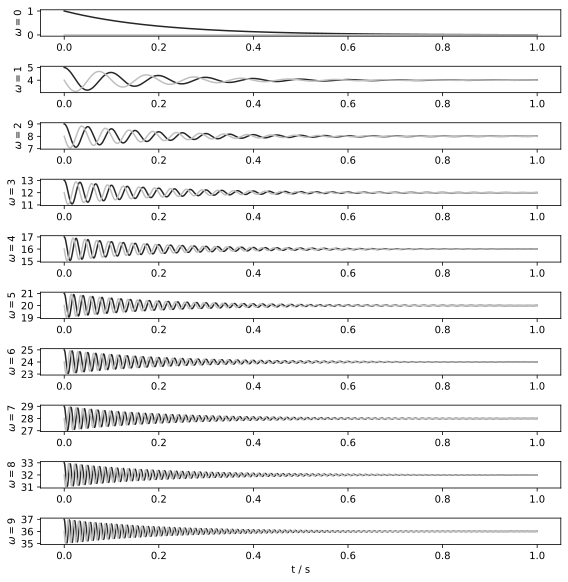

In [3]:
t = np.linspace(0,1,1000)

fig, axs = plt.subplots(10, 1, figsize=(8, 8))
#fig.suptitle('Different values for $\omega$ with a fixed $\omega$')

for i in range(10):        
    

    y = laplace(t,5,2 *np.pi *i*10,1) + 4*i
    axs[i].plot(t,y,color = [0.15,0.15,0.15])
    
    y = laplace(t,5,2 *np.pi *i*10,0) + 4*i
    axs[i].plot(t,y, color = [0.75,0.75,0.75])
    axs[i].set_ylabel('$\omega=$'+str(i)); 


plt.tight_layout()   
plt.xlabel('t / s');
    

----


# The S-Plane

The result of the Laplace transform can be visualized in the S-Plane, in its real and imaginary part:

$$
s = \sigma + j \omega 
$$

The decay term is plotted along the x-axis - the frequency term along the y-asis.


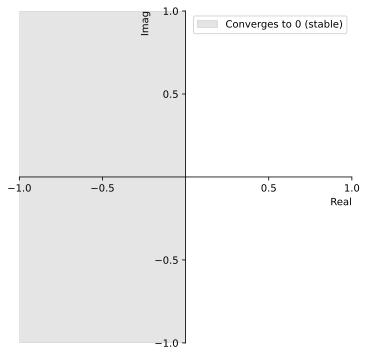

In [26]:
fig, ax = plt.subplots()

fig.set_figheight(6)
fig.set_figwidth(6)

ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

r = 1.5; plt.axis('scaled'); plt.axis([-r, r, -r, r])
ticks = [-1, -.5, .5, 1]; plt.xticks(ticks); plt.yticks(ticks)


plt.fill_between([-1,0], [1,1],-1 ,  color='gray', alpha=0.2, label='Converges to 0 (stable)');

#plt.plot(-0.5,0,'xk',label='Pole');

i
plt.xlabel('Real', loc='right')
plt.ylabel('Imag', loc='top')

plt.legend(loc=1)
plt.show()

-----

# LTI Analysis with Laplace

We can investigate the properties of LTI systems by analysing the Laplace transform of their impulse response $h(t)$:

$$
H(s) = \mathcal{L}\{h(t)\}
$$

The results will reveal if a system with a specific $h(t)$ is stable (and more).

-----

## Exponential Impulse Response

We assume a system with the following impulse response:

$$
h(t) = e^{-t}
$$

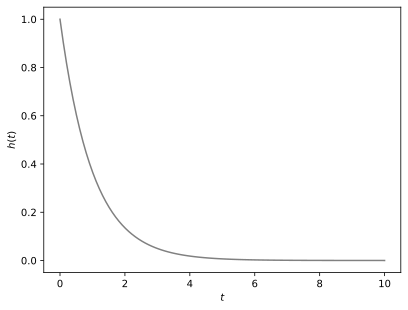

In [5]:
t = np.linspace(0,10,100)
x = np.exp(-t)

plt.plot(t,x, 'gray')
plt.xlabel('$t$')
plt.ylabel('$h(t)$');

The Laplace transform of this IR is
$$\begin{eqnarray}
F(s) & = & \int_{0}^{\infty} e^{-t} e^{-st} dt \\
& = & \int_{0}^{\infty} e^{-t} e^{-st} dt \\
& = & \int_{0}^{\infty}  e^{-t-st} dt \\
& = & \int_{0}^{\infty}  e^{-(s+1)t} dt \\
& = & \frac{-1}{1+s} e^{-(s+1)t} \Big|_{0}^{\infty} \\
& = & \left[ \frac{e^{-\infty} - e^{0}}{-1-s}   \right] \\
& = & \boxed{\frac{1}{s+1}}
\end{eqnarray}$$


Inserting  $s = \sigma + i \omega$:

$$\begin{eqnarray}
F(s) & = & {\frac{1}{\sigma + j \omega + 1}}
\end{eqnarray}$$

We see there is a pole at:

$$
\boxed{
\begin{eqnarray}
&\sigma=-1 \\
&\omega=0
\end{eqnarray}
}
$$


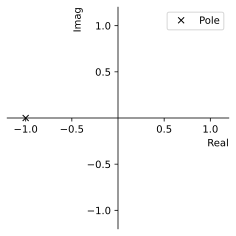

In [17]:
fig, ax = plt.subplots()

fig.set_figheight(4)
fig.set_figwidth(4)

ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

r = 1.5; plt.axis('scaled'); plt.axis([-r, r, -r, r])
ticks = [-1, -.5, .5, 1]; plt.xticks(ticks); plt.yticks(ticks)


# plt.fill_between([-1,0], [1,1],-1 ,color='none',hatch='//',edgecolor="gray",label='stable');

plt.plot(-1,0,'xk',label='Pole');

plt.xlim(-1.2,1.2)
plt.ylim(-1.2,1.2)

plt.xlabel('Real', loc='right')
plt.ylabel('Imag', loc='top')

plt.legend(loc=1)
plt.show()

With a pole at $\sigma=-1$, the function converges to $0$ - the LTI **system is stable**.

-----

## Exponential Impulse Response II

We can dramatically change the IR of the LTI system by changing the sign in the exponent:

$$
f(t) = e^t
$$

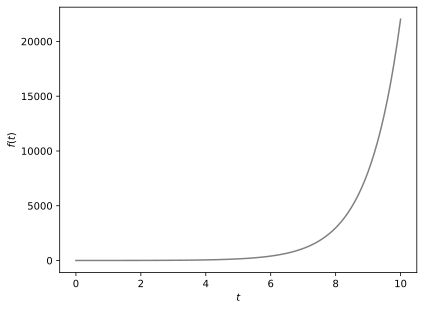

In [7]:
t = np.linspace(0,10,100)
x = np.exp(t)

plt.plot(t,x, 'gray')
plt.xlabel('$t$')
plt.ylabel('$f(t)$');

The Laplace transform of this IR is
$$\begin{eqnarray}
F(s) & = & \int_{0}^{\infty} e^t e^{-st} dt \\
& = & \int_{0}^{\infty} e^t e^{-st} dt \\
& = & \int_{0}^{\infty}  e^{t-st} dt \\
& = & \int_{0}^{\infty}  e^{-(s-1)t} dt \\
& = & \frac{1}{1-s}  e^{-(s-1)t} \Big|_{0}^{\infty} \\
& = & \left[ \frac{e^{-\infty} - e^{0}}{1-s}   \right] \\
& = & \boxed{\frac{1}{s-1}}
\end{eqnarray}$$


Inserting  $s = \sigma + i \omega$:

$$\begin{eqnarray}
F(s) & = & {\frac{1}{\sigma + j \omega -1}}
\end{eqnarray}$$

We see there is a pole at:

$$
\boxed{
\begin{eqnarray}
&\sigma=1 \\
&\omega=0
\end{eqnarray}
}
$$


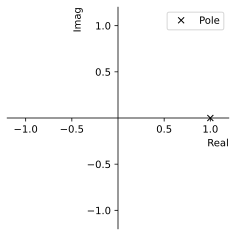

In [20]:
fig, ax = plt.subplots()

fig.set_figheight(4)
fig.set_figwidth(4)

ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

r = 1.5; plt.axis('scaled'); plt.axis([-r, r, -r, r])
ticks = [-1, -.5, .5, 1]; plt.xticks(ticks); plt.yticks(ticks)


# plt.fill_between([-1,0], [1,1],-1 ,color='none',hatch='//',edgecolor="gray",label='stable');

plt.plot(1,0,'xk',label='Pole');

plt.xlim(-1.2,1.2)
plt.ylim(-1.2,1.2)

plt.xlabel('Real', loc='right')
plt.ylabel('Imag', loc='top')

plt.legend(loc=1)
#plt.axis('square')
plt.show()

With a pole at $\sigma=1$, the IR converges to infinity and **the system is not stable**. 

-----

# Analysing a Circuit in the Laplace Domain

The Laplace transfom is use to analyse time-continuous LTI systems for example used in control theory and 
in electrical engineering - for circuit analysis.
Analysing a circuit with the Laplace transform means transforming its impulse response $h(t)$:
$$
H(s) = \int\limits_0^\infty h(t) e^{-s t}  dt  
$$


## RC Lowpass

The schematic below shows a first order RC lowpass.
It is one of the the simplest passive analog filters, with a resistor in series with a capacitor. 
The load is in parallel with the capacitor:


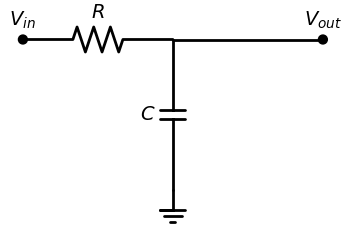

In [9]:
d = schem.Drawing()
d.add(e.Dot().label('$V_{in}$'))

d.add(e.Resistor().label('$R$'))
d.push() 

d.add(e.Capacitor().down().label('$C$'))

d.add(e.Ground())


d.pop()
d.add(e.Line().right())
d.add(e.Dot().label('$V_{out}$'))

d.draw()


-----


<div class="alert alert-block alert-info"> 
<b>A short note on Impedance</b> 
    
Impedance $Z$ is a complex, frequency-dependent extension of resistance:

$$
Z = R + jX
$$

The real part of impedance is the resistance $R$. It is the frequency-independent part of the impedance.
The imaginary part is called the reactance $X$.
In circuits, resistors only have a resistance, whereas circuit elements like capacitors and inductors are purely imaginary.


</div>



The impedance of the capacitor is purely imaginary and depends on its capacity $C$:

$$
Z_C = \frac{1}{sC}
$$


The capacitor has frequency-dependent behavior:
It lets high frequencies pass and attenuates lower frequencies,
ultimately blocking DC.


The resistor's impedance is purely real:

$$
Z_R = R
$$


The resistor limits the current - without it, there would be a short circuit and the capacitor would be without effect.
As a result, high frequencies will thus be *dragged* to the ground, whereas low frequencies cannot pass.

-----


## The Transfer Function


The transfer function of a circuit is defined as:

$$\begin{eqnarray}
H(s) & = & \frac{V_{out}}{V_{in}} \\
\end{eqnarray}
$$

It can be *assembled* following simple instructions:

- Everything between $V_{out}$ and ground goes into the denominator.
- Everything between $V_{in}$ and ground goes into the nominator.

The transfer function is then expanded to have the coefficient of highest power in the denominator
one - or unity:


$$\begin{eqnarray}
H(s) & = & \frac{Z_C}{Z_R + Z_C} \\
&=&  \frac{\frac{1}{sC}}{R+\frac{1}{sC}} \\
 & =&  \boxed{\frac{1}{1+sRC}}
\end{eqnarray}
$$

-----

## Time Constant and Cutoff Frequency

$RC$ is called the **time constant** $\tau$:

$$
\tau = RC
$$

The cutoff frequency $\omega_c$ is related to the time constant:

$$
\omega_c = \frac{1}{\tau} = \frac{1}{RC}
$$

Inserting $\omega_c$:

$$
H(s) = \frac{1}{1+\frac{s}{\omega_c}}
$$




With $\omega = 2 \pi f$ this results in:


$$
H(s) = \frac{1}{1+\frac{s}{2 \pi f_c}}
$$

-----

## Poles and Zeros

The above transfer function can be analysed in terms poles and zeros in the Laplace (S) plain:

- Zeros occur when the numerator is $0$. There are no zeros in this plot.

- Poles occur when the denominator is $0$. This circuit has a pole at:


$$
\boxed{s = \frac{-1}{\tau} = -\omega_c}
$$

It is negative and thus always stable - this makes sense for a passive RC lowpass: there is no feedback.

In [10]:
#fig, ax = plt.subplots()

#fig.set_figheight(4)
#fig.set_figwidth(4)

#ax.spines['left'].set_position('center')
#ax.spines['bottom'].set_position('center')
#ax.spines['right'].set_visible(False)
#ax.spines['top'].set_visible(False)

#r = 1.5; plt.axis('scaled'); plt.axis([-r, r, -r, r])
#ticks = [-1, -.5, .5, 1]; plt.xticks(ticks); plt.yticks(ticks)


# plt.fill_between([-1,0], [1,1],-1 ,color='none',hatch='//',edgecolor="gray",label='stable');

#plt.plot(-0.25,0,'xk',label='Pole at $-\omega_c$');

#plt.xlim(-1.2,1.2)

#plt.xlabel('Real')
#plt.ylabel('Imag')

#plt.legend(loc=1)
#plt.show()